# Notebook 5: Generate Estimated Tree Trunk Locations

Given crown polygons with known (or predicted) tree counts, this notebook generates a **point layer** of estimated tree trunk positions using constrained k-means clustering.

**Algorithm**: For each polygon containing N trees:
1. Sample ~2000 candidate points uniformly inside the polygon
2. Run k-means (N clusters) to find N evenly-spaced centroids
3. Each centroid represents one estimated tree location

This approximates a Centroidal Voronoi Tessellation — the resulting points partition the polygon into roughly equal-area sub-regions, consistent with the assumption that each tree's crown occupies a similar area.

**Inputs**: `train_set_validated.shp` (479 polygons with known trunk counts)
**Outputs**: Point shapefile with estimated tree locations

In [3]:
%pip install geopandas shapely scikit-learn matplotlib numpy pandas scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 5.1 Setup and Load Data

In [1]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from shapely.geometry import Point
import time

from tree_point_generator import generate_tree_points, generate_tree_points_gdf, compute_placement_quality

# ============================================================
# CONFIGURATION
# ============================================================
SHAPEFILE = "train_set_validated.shp"
OUTPUT_SHAPEFILE = "estimated_tree_locations.shp"
TARGET_CRS = 2039
# ============================================================

# Load and prepare data
gdf = gpd.read_file(SHAPEFILE).to_crs(epsg=TARGET_CRS)
gdf = gdf.explode(index_parts=False).reset_index(drop=True)
gdf = gdf[gdf.geometry.type == 'Polygon'].copy()

# Remove contained polygons
sindex = gdf.sindex
to_drop = set()
for idx, row in gdf.iterrows():
    if idx in to_drop:
        continue
    candidates = list(sindex.query(row.geometry, predicate='contains'))
    for c in candidates:
        if c != idx and c not in to_drop:
            if row.geometry.contains(gdf.iloc[c].geometry):
                to_drop.add(c)
gdf = gdf.drop(index=list(to_drop)).reset_index(drop=True)

print(f"Loaded {len(gdf)} polygons")
print(f"Tree count range: {gdf['Point_Coun'].min()} - {gdf['Point_Coun'].max()}")
print(f"Total trees: {gdf['Point_Coun'].sum()}")

Loaded 479 polygons
Tree count range: 2 - 44
Total trees: 3040


## 5.2 Demonstrate the Algorithm on Sample Polygons

Visualize how tree points are placed inside polygons of different shapes and sizes.

D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

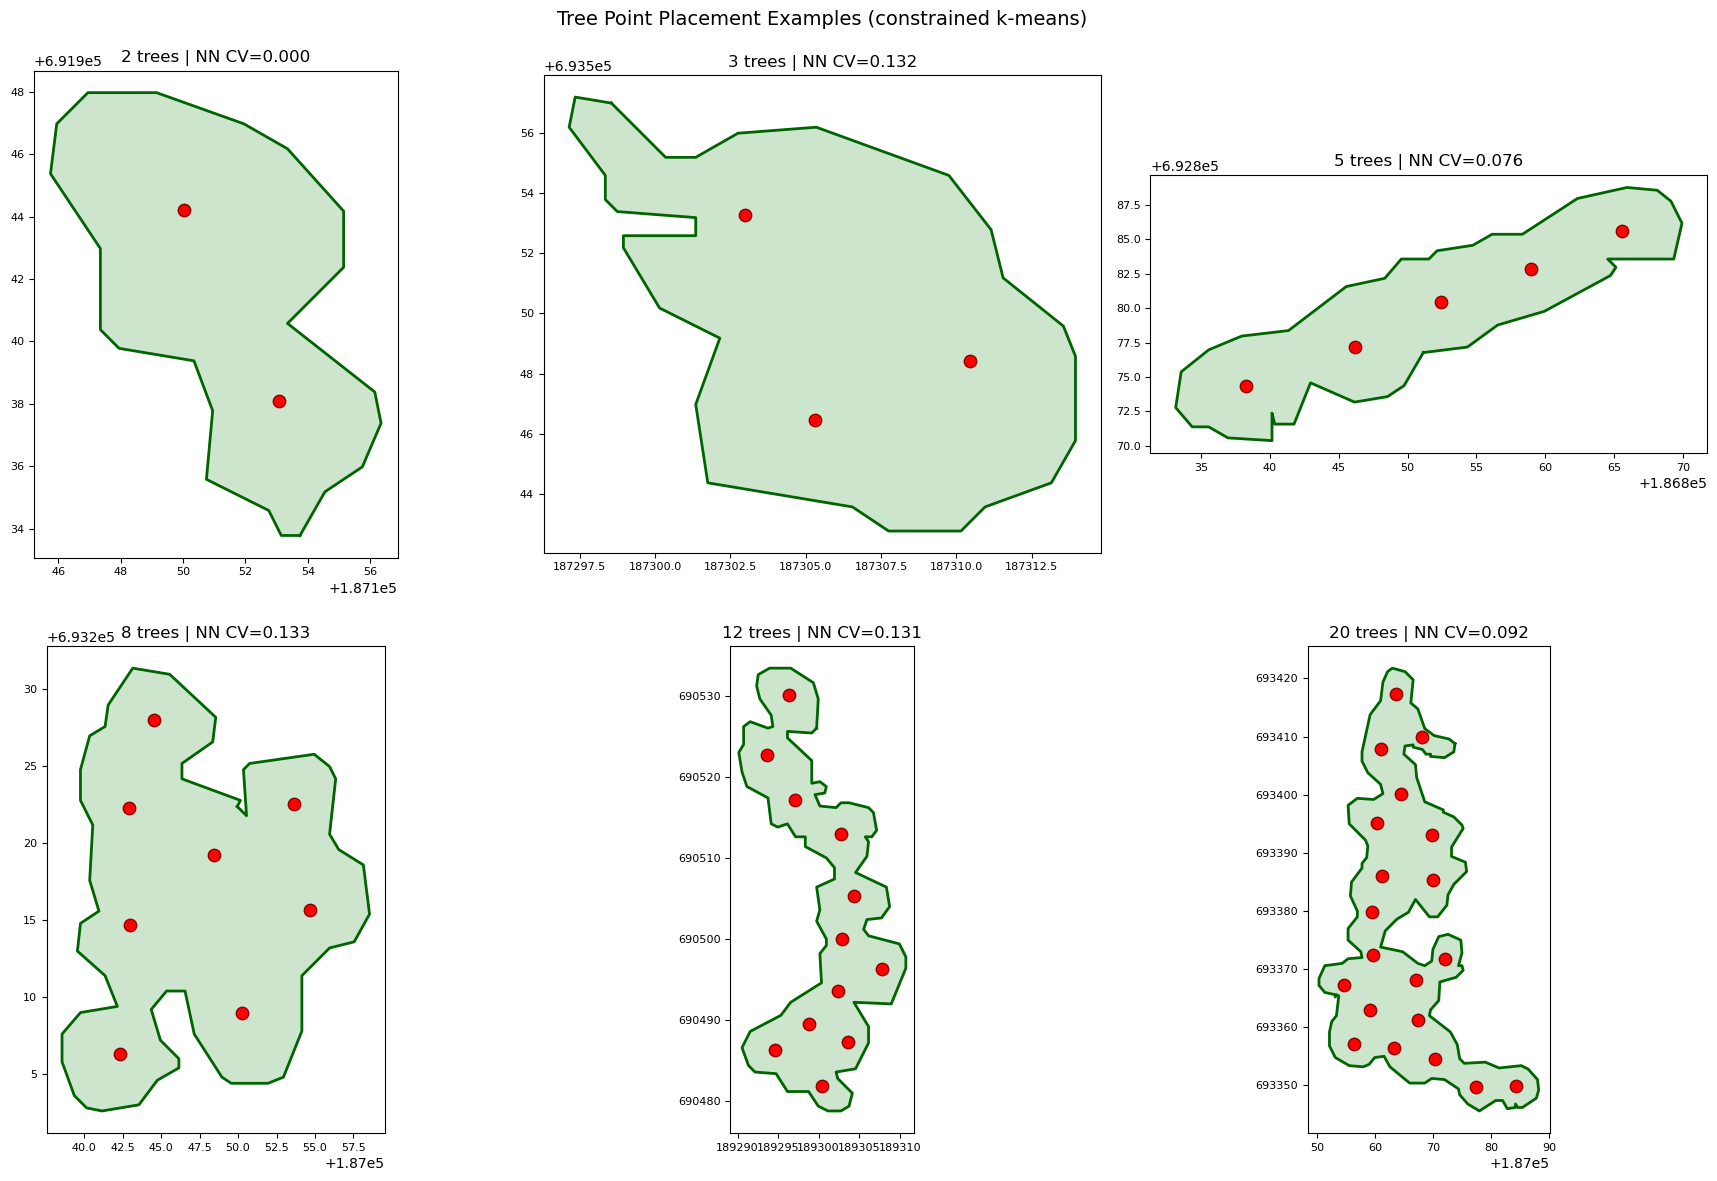

In [2]:
# Select sample polygons with varying tree counts and shapes
samples = []
for target_count in [2, 3, 5, 8, 12, 20]:
    candidates = gdf[gdf['Point_Coun'] == target_count]
    if len(candidates) > 0:
        # Pick the one with median area for this count
        median_area = candidates.geometry.area.median()
        best_idx = (candidates.geometry.area - median_area).abs().idxmin()
        samples.append(best_idx)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, idx in enumerate(samples):
    ax = axes[i]
    row = gdf.loc[idx]
    polygon = row.geometry
    n_trees = int(row['Point_Coun'])

    # Generate tree points
    points = generate_tree_points(polygon, n_trees)

    # Plot polygon
    x, y = polygon.exterior.xy
    ax.fill(x, y, alpha=0.2, color='green')
    ax.plot(x, y, color='darkgreen', linewidth=2)

    # Plot tree points
    px = [p.x for p in points]
    py = [p.y for p in points]
    ax.scatter(px, py, c='red', s=80, zorder=5, edgecolors='darkred', linewidth=1)

    # Compute quality metrics
    quality = compute_placement_quality(polygon, points)

    ax.set_title(f'{n_trees} trees | NN CV={quality["cv_nn_dist"]:.3f}', fontsize=12)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=8)

fig.suptitle('Tree Point Placement Examples (constrained k-means)', fontsize=14)
fig.tight_layout()
plt.show()

## 5.3 Generate Tree Points for All Polygons

In [3]:
print(f"Generating tree points for {len(gdf)} polygons ({gdf['Point_Coun'].sum()} total trees)...")
t0 = time.time()

points_gdf = generate_tree_points_gdf(gdf, count_column='Point_Coun', n_samples=2000, random_state=42)

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")
print(f"Generated {len(points_gdf)} tree point locations")
print(f"Points per polygon: {points_gdf.groupby('polygon_id').size().describe().to_string()}")

Generating tree points for 479 polygons (3040 total trees)...


D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

Done in 120.7s
Generated 3040 tree point locations
Points per polygon: count    479.000000
mean       6.346555
std        5.166773
min        2.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       44.000000


D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


## 5.4 Placement Quality Analysis

Evaluate how evenly the points are distributed within each polygon using the coefficient of variation (CV) of nearest-neighbor distances. Lower CV = more uniform spacing.

In [4]:
# Compute quality metrics for each polygon (skip n_trees=1)
quality_records = []
for idx, row in gdf.iterrows():
    n_trees = int(row['Point_Coun'])
    if n_trees < 2:
        continue
    pts = points_gdf[points_gdf['polygon_id'] == idx]
    point_list = list(pts.geometry)
    q = compute_placement_quality(row.geometry, point_list)
    q['n_trees'] = n_trees
    q['polygon_id'] = idx
    q['area'] = row.geometry.area
    # Compute area per tree (proxy for expected crown size)
    q['area_per_tree'] = row.geometry.area / n_trees
    quality_records.append(q)

import pandas as pd
quality_df = pd.DataFrame(quality_records)

print("Placement quality summary:")
print(quality_df[['cv_nn_dist', 'mean_nn_dist', 'min_edge_dist']].describe().round(3).to_string())
print(f"\nMean NN distance CV: {quality_df['cv_nn_dist'].mean():.4f}")
print(f"Median NN distance CV: {quality_df['cv_nn_dist'].median():.4f}")
print(f"% of polygons with CV < 0.2 (highly uniform): {(quality_df['cv_nn_dist'] < 0.2).mean()*100:.1f}%")

Placement quality summary:
       cv_nn_dist  mean_nn_dist  min_edge_dist
count     479.000       479.000        479.000
mean        0.090         6.901          1.988
std         0.068         1.815          0.970
min         0.000         2.930          0.010
25%         0.033         5.660          1.350
50%         0.087         6.800          1.960
75%         0.139         7.910          2.485
max         0.377        14.820          5.640

Mean NN distance CV: 0.0900
Median NN distance CV: 0.0874
% of polygons with CV < 0.2 (highly uniform): 94.2%


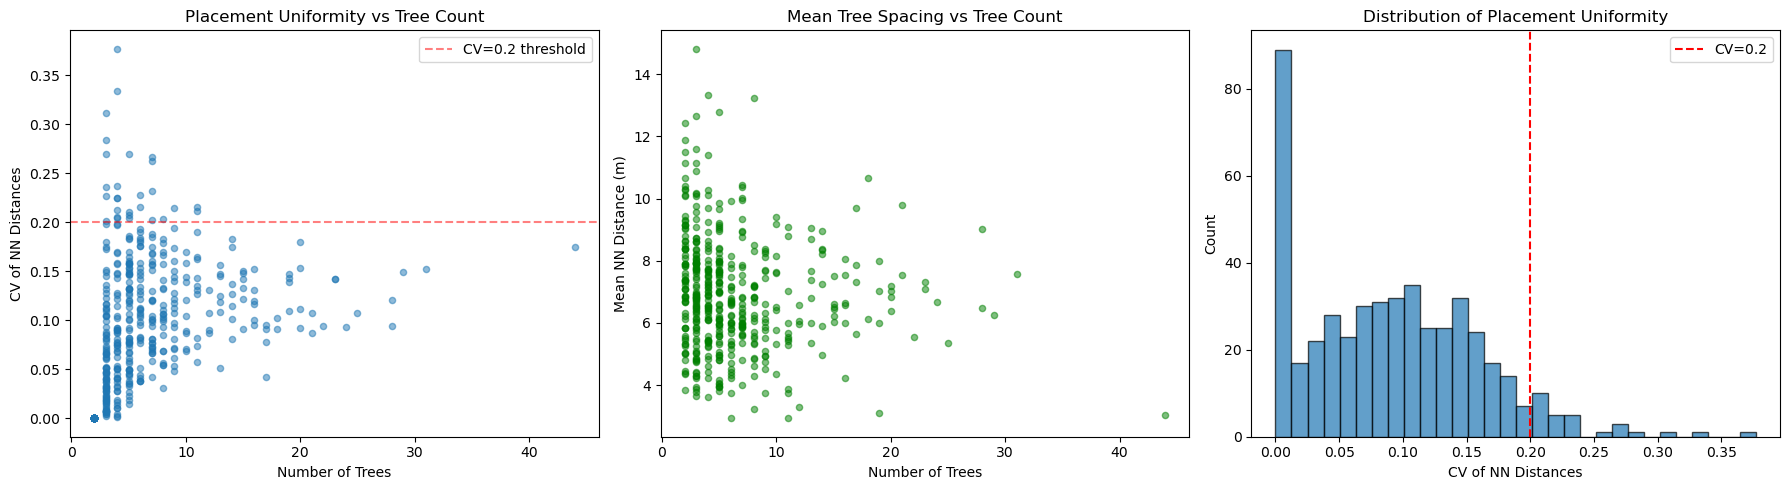

In [5]:
# Quality vs tree count
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(quality_df['n_trees'], quality_df['cv_nn_dist'], alpha=0.5, s=20)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('CV of NN Distances')
ax.set_title('Placement Uniformity vs Tree Count')
ax.axhline(0.2, color='red', linestyle='--', alpha=0.5, label='CV=0.2 threshold')
ax.legend()

ax = axes[1]
ax.scatter(quality_df['n_trees'], quality_df['mean_nn_dist'], alpha=0.5, s=20, color='green')
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Mean NN Distance (m)')
ax.set_title('Mean Tree Spacing vs Tree Count')

ax = axes[2]
ax.hist(quality_df['cv_nn_dist'], bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('CV of NN Distances')
ax.set_ylabel('Count')
ax.set_title('Distribution of Placement Uniformity')
ax.axvline(0.2, color='red', linestyle='--', label='CV=0.2')
ax.legend()

fig.tight_layout()
plt.show()

## 5.5 Spatial Overview

Map showing all generated tree points overlaid on the crown polygons.

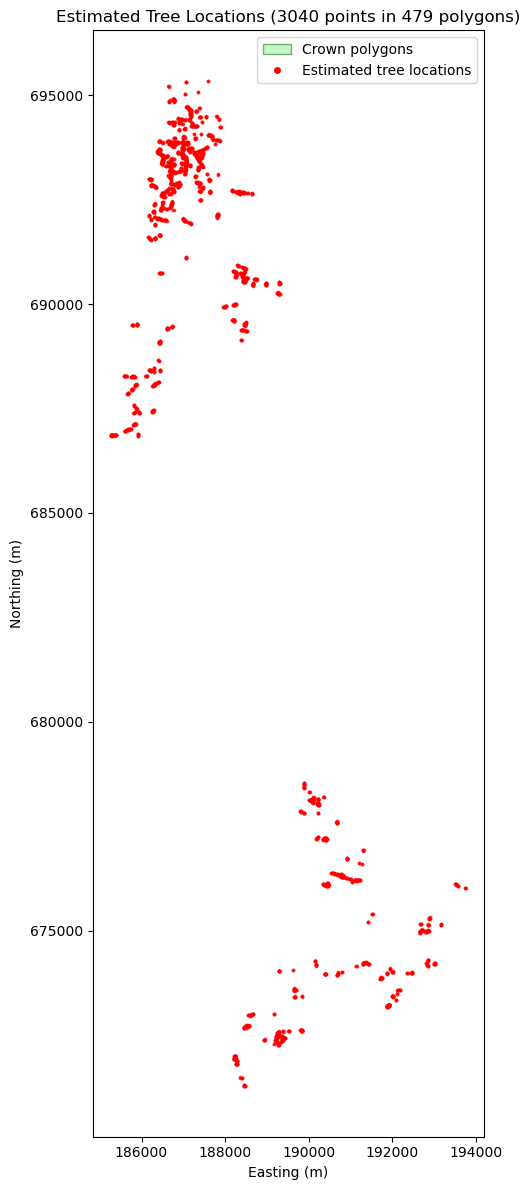

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Plot polygons
gdf.plot(ax=ax, facecolor='lightgreen', edgecolor='darkgreen', linewidth=0.5, alpha=0.5)

# Plot tree points
points_gdf.plot(ax=ax, color='red', markersize=3, alpha=0.6)

ax.set_title(f'Estimated Tree Locations ({len(points_gdf)} points in {len(gdf)} polygons)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.ticklabel_format(style='plain')
ax.legend(handles=[
    Patch(facecolor='lightgreen', edgecolor='darkgreen', alpha=0.5, label='Crown polygons'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=6, label='Estimated tree locations'),
], loc='upper right')
fig.tight_layout()
plt.show()

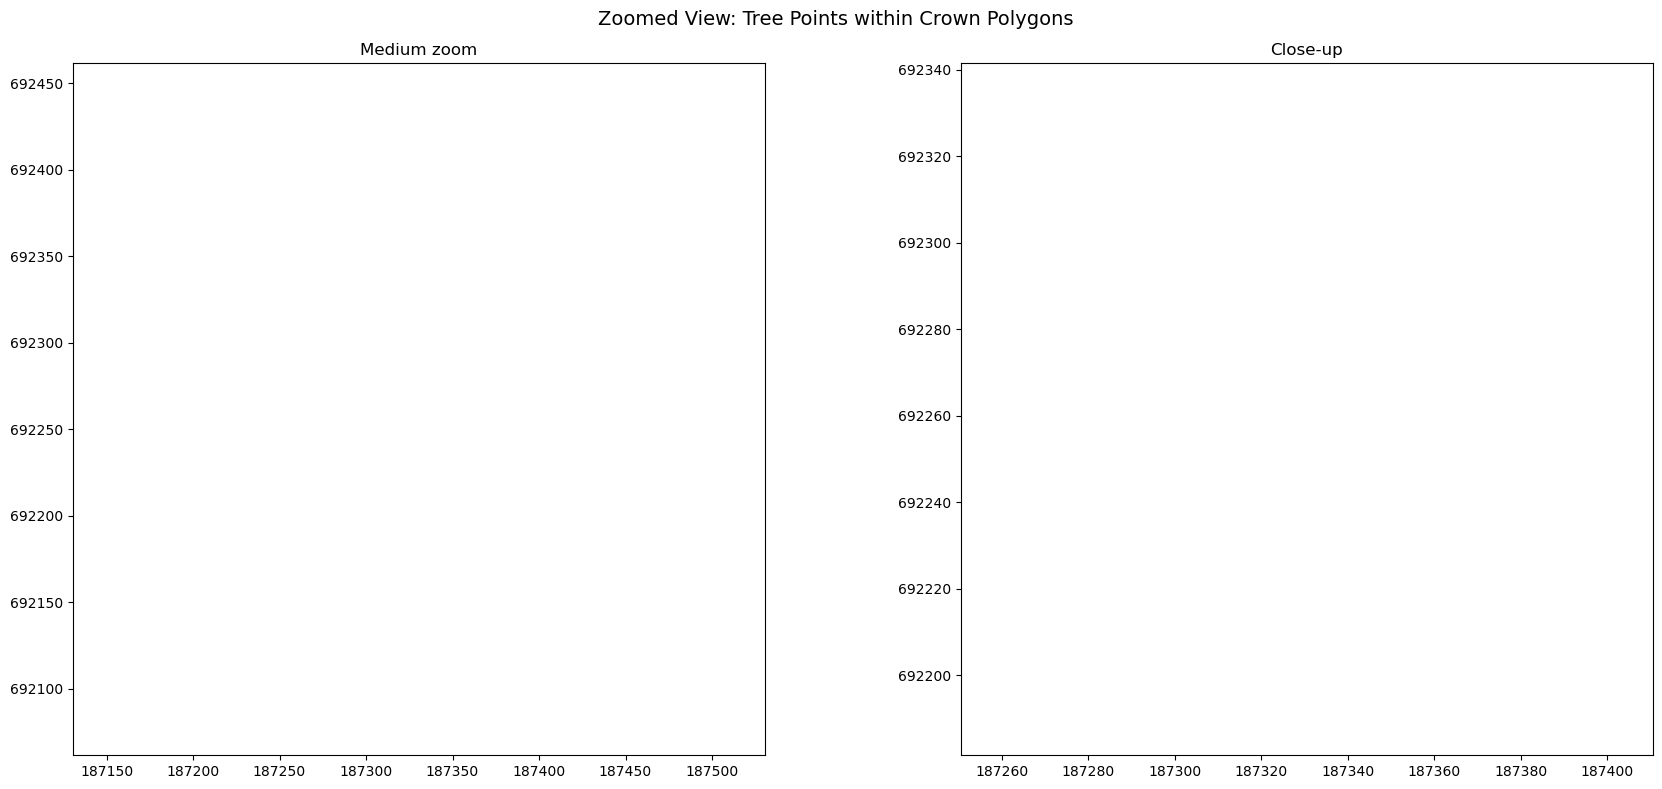

In [7]:
# Zoomed view of a dense area
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pick a region with many polygons close together
centroids = gdf.geometry.centroid
cx, cy = centroids.x.median(), centroids.y.median()

for ax, zoom, title in zip(axes, [200, 80], ['Medium zoom', 'Close-up']):
    gdf.plot(ax=ax, facecolor='lightgreen', edgecolor='darkgreen', linewidth=1, alpha=0.4)
    points_gdf.plot(ax=ax, color='red', markersize=15, alpha=0.8, edgecolors='darkred', linewidth=0.5)
    ax.set_xlim(cx - zoom, cx + zoom)
    ax.set_ylim(cy - zoom, cy + zoom)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.ticklabel_format(style='plain')

fig.suptitle('Zoomed View: Tree Points within Crown Polygons', fontsize=14)
fig.tight_layout()
plt.show()

## 5.6 Crown Area per Tree Analysis

Since we assume equal crown areas within each polygon, we can estimate the average crown area and equivalent crown diameter per tree.

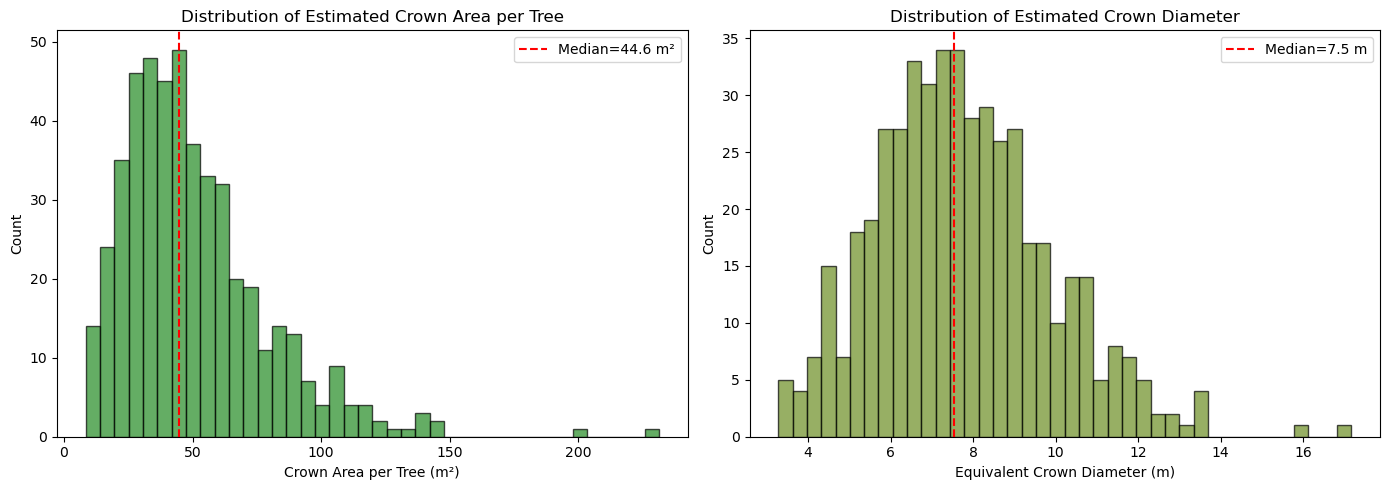

Crown area per tree:  median=44.6 m², mean=50.8 m², range=[8.4, 231.4]
Crown diameter:       median=7.5 m, mean=7.8 m, range=[3.3, 17.2]


In [8]:
gdf['area_per_tree'] = gdf.geometry.area / gdf['Point_Coun']
gdf['crown_diameter'] = 2 * np.sqrt(gdf['area_per_tree'] / np.pi)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(gdf['area_per_tree'], bins=40, edgecolor='black', alpha=0.7, color='forestgreen')
ax.set_xlabel('Crown Area per Tree (m²)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Estimated Crown Area per Tree')
ax.axvline(gdf['area_per_tree'].median(), color='red', linestyle='--',
           label=f'Median={gdf["area_per_tree"].median():.1f} m²')
ax.legend()

ax = axes[1]
ax.hist(gdf['crown_diameter'], bins=40, edgecolor='black', alpha=0.7, color='olivedrab')
ax.set_xlabel('Equivalent Crown Diameter (m)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Estimated Crown Diameter')
ax.axvline(gdf['crown_diameter'].median(), color='red', linestyle='--',
           label=f'Median={gdf["crown_diameter"].median():.1f} m')
ax.legend()

fig.tight_layout()
plt.show()

print(f"Crown area per tree:  median={gdf['area_per_tree'].median():.1f} m², "
      f"mean={gdf['area_per_tree'].mean():.1f} m², range=[{gdf['area_per_tree'].min():.1f}, {gdf['area_per_tree'].max():.1f}]")
print(f"Crown diameter:       median={gdf['crown_diameter'].median():.1f} m, "
      f"mean={gdf['crown_diameter'].mean():.1f} m, range=[{gdf['crown_diameter'].min():.1f}, {gdf['crown_diameter'].max():.1f}]")

## 5.7 Save Output Shapefile

In [9]:
# Rename columns for shapefile compatibility (10-char limit)
output_gdf = points_gdf.rename(columns={
    'polygon_id': 'poly_id',
    'tree_count': 'tree_cnt',
    'tree_index': 'tree_idx',
})

output_gdf.to_file(OUTPUT_SHAPEFILE)
print(f"Saved {len(output_gdf)} tree points to: {OUTPUT_SHAPEFILE}")
print(f"Columns: {list(output_gdf.columns)}")
print(f"CRS: {output_gdf.crs}")
print(f"\nOpen {OUTPUT_SHAPEFILE} in QGIS/ArcGIS alongside the crown polygons to visualize.")

Saved 3040 tree points to: estimated_tree_locations.shp
Columns: ['geometry', 'poly_id', 'tree_cnt', 'tree_idx']
CRS: EPSG:2039

Open estimated_tree_locations.shp in QGIS/ArcGIS alongside the crown polygons to visualize.


## 5.8 Summary

**Algorithm**: Constrained k-means places N evenly-spaced points inside each polygon, approximating a Centroidal Voronoi Tessellation. This assumes each tree occupies a roughly equal share of the merged crown area.

**Key outputs**:
- `estimated_tree_locations.shp` — point layer with one point per estimated tree trunk
- Each point carries: polygon ID, tree count for that polygon, tree index within the polygon

**Limitations**:
- Assumes equal crown areas within each polygon (no dominant/suppressed trees)
- Point locations are statistical estimates, not actual trunk positions
- Accuracy depends on the quality of the trunk count prediction (from the ML model)
- For very elongated or highly concave polygons, the algorithm may produce suboptimal spacing

**Integration with the full pipeline**:
1. Predict trunk counts using the model from Notebook 2/3
2. Feed predictions into `generate_tree_points_gdf()` to get point locations
3. Use the resulting point layer for urban tree inventory, planning, or further analysis